
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]** \
Here we have used smaller batch size and image preprocessing to balance memeory vs speed. We have also used callbacks such as EarlyStopping and ReduceLROnPlateau to speed up training and avoid overfitting. Finally, since we have used tensorflow, it leverages hardware acceleration (GPU/TPU) and TensorFlow’s runtime optimizations. \
\
All of the above are not explicitly listed in the lecture slides but substantially reduce training time.

---



## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

In [2]:
sys.modules

{'sys': <module 'sys' (built-in)>,
 'builtins': <module 'builtins' (built-in)>,
 '_frozen_importlib': <module '_frozen_importlib' (frozen)>,
 '_imp': <module '_imp' (built-in)>,
 '_thread': <module '_thread' (built-in)>,
 '_warnings': <module '_warnings' (built-in)>,
 '_weakref': <module '_weakref' (built-in)>,
 '_io': <module '_io' (built-in)>,
 'marshal': <module 'marshal' (built-in)>,
 'posix': <module 'posix' (built-in)>,
 '_frozen_importlib_external': <module '_frozen_importlib_external' (frozen)>,
 'time': <module 'time' (built-in)>,
 'zipimport': <module 'zipimport' (frozen)>,
 '_codecs': <module '_codecs' (built-in)>,
 'codecs': <module 'codecs' (frozen)>,
 'encodings.aliases': <module 'encodings.aliases' from '/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/encodings/aliases.py'>,
 'encodings': <module 'encodings' from '/hpctmp/e1554287/conda/envs/ai1008/lib/python3.13/encodings/__init__.py'>,
 'encodings.utf_8': <module 'encodings.utf_8' from '/hpctmp/e1554287/conda/envs/ai

In [2]:

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

No GPU was detected. CNNs can be very slow without a GPU.
Versions of key libraries
---
tensorflow:  2.18.0
numpy:       2.3.3
matplotlib:  3.10.6
sklearn:     1.7.2


## **2. Matplotlib setup**
applies a Matplotlib style sheet that imitates the look of R’s ggplot2.\
It changes colors, gridlines, and overall chart aesthetics (light gray background, white grid, red/blue lines)

In [30]:
import matplotlib.font_manager

# List all font names Matplotlib can find
for f in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist])):
    print(f)

AR PL UMing CN
Abyssinica SIL
C059
Caladea
Cantarell
Carlito
D050000L
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
FreeMono
FreeSans
FreeSerif
Inconsolata
Jomolhari
Khmer OS
Khmer OS Content
Khmer OS System
LKLUG
Liberation Mono
Liberation Sans
Liberation Serif
Lohit Assamese
Lohit Bengali
Lohit Devanagari
Lohit Gujarati
Lohit Kannada
Lohit Malayalam
Lohit Marathi
Lohit Nepali
Lohit Oriya
Lohit Punjabi
Lohit Tamil
Lohit Telugu
Madan2
Meera
NanumGothic
Nimbus Mono PS
Nimbus Roman
Nimbus Sans
Nimbus Sans Narrow
Noto Emoji
Nuosu SIL
Open Sans
Overpass
P052
PT Sans
PT Sans Narrow
Padauk
PakType Naskh Basic
STIX
STIXGeneral
STIXNonUnicode
STIXSizeFiveSym
STIXSizeFourSym
STIXSizeOneSym
STIXSizeThreeSym
STIXSizeTwoSym
Source Code Pro
URW Bookman
URW Gothic
Ubuntu
Ubuntu Condensed
Ubuntu Mono
VL Gothic
Waree
WenQuanYi Micro Hei
WenQuanYi Zen Hei
Z003
cmb10
cmex10
cmmi10
cmr10
cmss10
cmsy10
cmtt10


In [31]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['font.family']	= 'FreeSerif'

## **3. Data preparation**
For deep learning training and
testing, the data must be in the
form of (sample, row, clm, channel)


In [4]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step


In [5]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_test.shape)
print("y_train.shape =", y_test.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_test.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (10000, 32, 32, 3, 1)
y_train.shape = (10000, 1)
X_valid.shape = (5000, 32, 32, 3, 1)
y_valid.shape = (10000, 1)
X_test.shape = (10000, 32, 32, 3, 1)
y_test.shape = (10000, 1)


In [18]:
X_train_full[1].astype('float32') / 255.0

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [24]:
# we can do the same as above by converting to float 0-1 values:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Convert pixel values from integers (0–255) to floats (0–1) for normalization
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Split the full training data into training (45,000) and validation (5,000)
# X_train_full has shape (50,000, 32, 32, 3)
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Compute the mean image of the training set for normalization
# X_mean shape = (1, 32, 32, 3)
X_mean = X_train.mean(axis=0, keepdims=True)
# Compute standard deviation per pixel, add small epsilon (1e-7) to avoid division by zero
# X_std shape = (1, 32, 32, 3)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
# Standardize each dataset: subtract mean and divide by std-dev
# Keeps shape (N, 32, 32, 3)
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# (OPTIONAL) Expand dimensions for grayscale models (e.g., CNNs expecting single channel)
# But for RGB data this is unnecessary — each sample already has 3 channels.
# Running this line repeatedly keeps adding a redundant axis:
# (N, 32, 32, 3) → (N, 32, 32, 3, 1) → (N, 32, 32, 3, 1, 1) etc.
# X_train = X_train[..., np.newaxis]
# X_valid = X_valid[..., np.newaxis]
# X_test = X_test[..., np.newaxis]

print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_train.shape)
print("y_train.shape =", y_train.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_valid.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)

X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (45000, 32, 32, 3)
y_train.shape = (45000, 1)
X_valid.shape = (5000, 32, 32, 3)
y_valid.shape = (5000, 1)
X_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)


In [22]:
 X_train_full[:-5000].shape

(45000, 32, 32, 3)

In [25]:
X_train[0] #i-th image, a (32, 32, 3) array

array([[[-0.9780905 , -1.0155901 , -0.86447954],
        [-1.2041487 , -1.2434839 , -1.0908533 ],
        [-1.1232789 , -1.2306316 , -1.1276528 ],
        ...,
        [ 0.37097213, -0.0603633 , -0.30723262],
        [ 0.29604748, -0.14860915, -0.3759899 ],
        [ 0.24232915, -0.15834126, -0.36081332]],

       [[-1.5706078 , -1.5963941 , -1.3930682 ],
        [-1.800957  , -1.8837535 , -1.6470648 ],
        [-1.56918   , -1.7898387 , -1.6609584 ],
        ...,
        [-0.1001865 , -0.6644354 , -0.96231085],
        [-0.14488004, -0.7219888 , -1.0159235 ],
        [-0.09982532, -0.6589659 , -0.9231761 ]],

       [[-1.4553089 , -1.5467734 , -1.3787966 ],
        [-1.5869025 , -1.7912263 , -1.6452698 ],
        [-1.1408373 , -1.5269681 , -1.558894  ],
        ...,
        [-0.16080172, -0.71400833, -1.0177556 ],
        [-0.12254331, -0.7028068 , -1.0093951 ],
        [-0.27481788, -0.8516099 , -1.1077774 ]],

       ...,

       [[ 1.2636023 ,  0.70716774, -0.27808568],
        [ 1

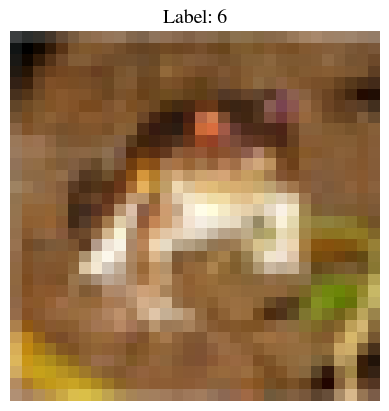

/var/tmp/pbs.246618.venus01/ipykernel_5178/42967437.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(y_train_full[i]))  # label as title


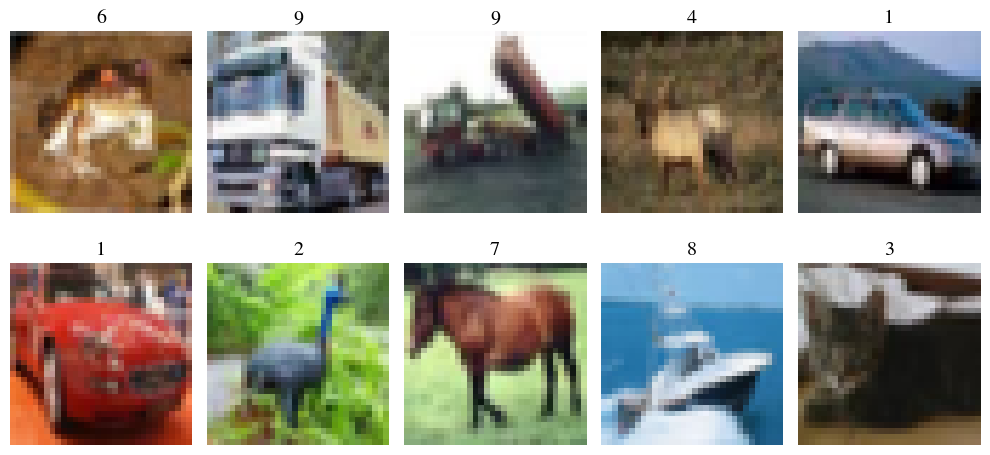

In [32]:
# Show one image
plt.imshow(X_train_full[0])       # displays the first image
plt.title(f"Label: {y_train_full[0][0]}")
plt.axis('off')
plt.show()

# Show a few images in a grid
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(int(y_train_full[i]))  # label as title
    plt.axis('off')
plt.tight_layout()
plt.show()

## **4. Define model**

In [6]:
# DNN model here
imgrows=X_train_full.shape[1]
imgclms=X_train_full.shape[2]
channel=3
num_classes = 10

model = keras.Sequential()
model.add(keras.layers.Dense(512, activation='relu', input_dim=3072))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,804,682 (6.88 MB)

 Trainable params: 1,804,682 (6.88 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [34]:
seed = 29
np.random.seed(seed)

In [38]:
# Set up optimizer
# from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau

optmz = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])

# create checkpoints to save model during training and save training data into csv
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
modelname = "cifar10"
filepath = modelname + ".keras"
# Save best model (by validation accuracy)
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=0, save_best_only=True, mode='max')
# checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=0, save_best_only=True, mode='min') #can also use loss
# Log training history to CSV
csv_logger = CSVLogger(modelname + '.csv')

# Stop early if val accuracy doesn't improve for 'patience' epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',     # or 'val_loss' if that’s your key metric
    patience=10,                # wait 10 epochs before stopping
    restore_best_weights=True,  # restore model weights from best epoch
    verbose=1
) #restore_best_weights=True ensures you keep the best model parameters when early stopping triggers.

# Reduce learning rate when performance plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,                 # halve LR each time
    patience=5,                 # wait 5 epochs before reducing
    min_lr=1e-6,                # floor for LR
    verbose=1
) #ReduceLROnPlateau is very helpful on HPC runs — it prevents overfitting and saves compute time by dynamically adapting LR.

# Combine all callbacks
callbacks_list = [checkpoint, csv_logger, early_stop, reduce_lr]



#### We use Sequential
* The model is strictly linear — one layer feeds directly into the next.
* You don’t have multiple inputs, multiple outputs, or branching connections.
* Typical for simple feedforward, CNN, or LSTM stacks.
* Simple and compact readability
* Think of it like stacking Lego blocks in a straight line — one after another.

In [35]:
def createModel():
    model = Sequential()
    model.add(Conv2D(32,(3,3),
            input_shape=(imgrows,
                        imgclms,
                        channel),
            padding='same',
            activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(48,(3,3),
            padding='same',
            activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(64,(3,3),
            padding='same',
            activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Flatten())

    model.add(Dense(256,activation='relu'))
    model.add(Dense(num_classes,activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                optimizer=optmz,
                metrics=['accuracy'])
    return model

In [36]:
model = createModel()
modelGo = createModel()

model.summary()

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,112,134 (8.06 MB)

 Trainable params: 307,450 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,804,684 (6.88 MB)

In [41]:
modelGo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,112,134 (8.06 MB)

 Trainable params: 307,450 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,804,684 (6.88 MB)

## **5 & 6. Train and test a model**

### CNN

In [39]:
model.fit(X_train,
        y_train_encoded,
        validation_data=(X_valid, y_valid_encoded),
        epochs=100,
        batch_size=128,
        shuffle=True,
        callbacks=callbacks_list,
        verbose=2)  # <-- recommended for SSH/HPC use


Epoch 1/100
352/352 - 19s - 54ms/step - accuracy: 0.3603 - loss: 1.8100 - val_accuracy: 0.4340 - val_loss: 1.5830 - learning_rate: 1.0000e-04
Epoch 2/100
352/352 - 18s - 51ms/step - accuracy: 0.4677 - loss: 1.5045 - val_accuracy: 0.4800 - val_loss: 1.4578 - learning_rate: 1.0000e-04
Epoch 3/100
352/352 - 18s - 52ms/step - accuracy: 0.5108 - loss: 1.3838 - val_accuracy: 0.5274 - val_loss: 1.3507 - learning_rate: 1.0000e-04
Epoch 4/100
352/352 - 18s - 52ms/step - accuracy: 0.5406 - loss: 1.3041 - val_accuracy: 0.5372 - val_loss: 1.3159 - learning_rate: 1.0000e-04
Epoch 5/100
352/352 - 18s - 51ms/step - accuracy: 0.5670 - loss: 1.2420 - val_accuracy: 0.5582 - val_loss: 1.2795 - learning_rate: 1.0000e-04
Epoch 6/100
352/352 - 18s - 51ms/step - accuracy: 0.5843 - loss: 1.1934 - val_accuracy: 0.5872 - val_loss: 1.1851 - learning_rate: 1.0000e-04
Epoch 7/100
352/352 - 18s - 51ms/step - accuracy: 0.6007 - loss: 1.1490 - val_accuracy: 0.5988 - val_loss: 1.1673 - learning_rate: 1.0000e-04
Epoch 

In [45]:
#**entire model** — architecture + weights + optimizer state if saved using `model.save()
modelGo = tf.keras.models.load_model(filepath)

# Only the weights — no model architecture. Must be loaded into an identical model definition
# modelGo.load_weights('cifar10.weights.h5')
modelGo.compile(loss='categorical_crossentropy',
             optimizer=optmz,
             metrics=['accuracy'])

In [47]:
predicts = modelGo.predict(X_test)
predout = np.argmax(predicts,axis=1)
testout = np.argmax(y_test_encoded,axis=1)
labelname = ['airplane',
            'automobile',
            'bird',
            'cat',
            'deer',
            'dog',
            'frog',
            'horse',
            'ship',
            'truck']
testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=labelname,digits=4))
print(confusion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Best accuracy (on testing dataset): 71.22%
              precision    recall  f1-score   support

    airplane     0.7289    0.7530    0.7408      1000
  automobile     0.8416    0.8180    0.8296      1000
        bird     0.5647    0.6590    0.6082      1000
         cat     0.5078    0.5530    0.5294      1000
        deer     0.7065    0.6330    0.6677      1000
         dog     0.6207    0.6070    0.6138      1000
        frog     0.8054    0.7820    0.7935      1000
       horse     0.7654    0.7470    0.7561      1000
        ship     0.8231    0.8140    0.8185      1000
       truck     0.8138    0.7560    0.7838      1000

    accuracy                         0.7122     10000
   macro avg     0.7178    0.7122    0.7141     10000
weighted avg     0.7178    0.7122    0.7141     10000

[[753  10  68  32  15   6   8  10  61  37]
 [ 27 818  17  16   5   3   7   5  28  74]
 [ 61   3 659  59  69  54  45  34   8   8]
 [ 20   6 102 553  48 171  4

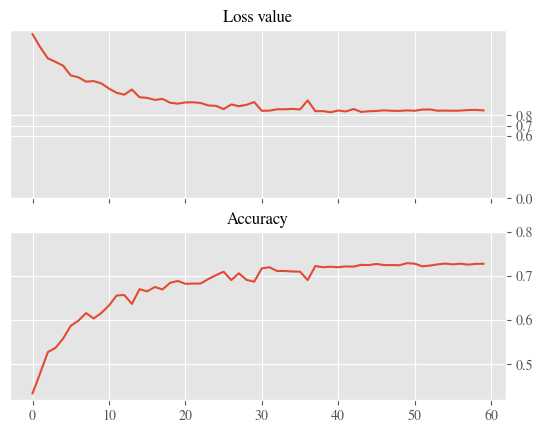

In [49]:
import pandas as pd
records = pd.read_csv(modelname +'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)


ax = plt.gca()
ax.set_xticklabels([])


plt.subplot(212)
plt.plot(records['val_accuracy'])
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()

### DNN

In [9]:
# train a model
# Note: Reshape the input data to flatten the images (for DNN)
X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # -1 infers the remaining dimension
X_valid_flattened = X_valid.reshape(X_valid.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
X_train = X_train_flattened
X_valid = X_valid_flattened
X_test = X_test_flattened

history = model.fit(X_train, y_train_encoded, epochs=4, validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list)
score = model.evaluate(X_test, y_test_encoded)
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/4
1399/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3616 - loss: 1.7961

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4109 - loss: 1.6659 - val_accuracy: 0.4440 - val_loss: 1.5591
Epoch 2/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5024 - loss: 1.4246 - val_accuracy: 0.4822 - val_loss: 1.4683
Epoch 3/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5493 - loss: 1.2954 - val_accuracy: 0.4918 - val_loss: 1.4386
Epoch 4/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5834 - loss: 1.1894 - val_accuracy: 0.5188 - val_loss: 1.4100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5195 - loss: 1.4158
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [10]:
model.save_weights(modelname+".weights.h5", overwrite=True)
print (X_test.shape)
print (y_test_encoded.shape)
print (score)

print ("modelname =", modelname)
!pwd
!date
!ls -lh

(10000, 3072)
(10000, 10)
[1.4158281087875366, 0.5195000171661377]
modelname = cifar10
/home/svu/e1554287/projects/ideal-ML-train/deep-learning
Wed Oct 22 08:46:03 +08 2025
total 78M
-rw------- 1 e1554287 svuusers  47K Oct 22 08:14 8_1_text_generation_with_lstm.ipynb
-rw-r--r-- 1 e1554287 svuusers  357 Oct 22 08:46 cifar10.csv
-rw-r--r-- 1 e1554287 svuusers  14M Oct 22 08:46 cifar10.keras
-rw-r--r-- 1 e1554287 svuusers  14M Oct 22 08:46 cifar10.weights.h5
-rw------- 1 e1554287 svuusers  26K Oct 22 08:16 D2GRNN.ipynb
-rw------- 1 e1554287 svuusers 112K Oct 21 09:31 D4_CNN_psupr_wks5_5.ipynb
-rw------- 1 e1554287 svuusers 470K Oct 22 08:14 dual_shared_input_network_cifar10.ipynb
-rw------- 1 e1554287 svuusers  245 Oct  9 08:41 Export and Submission Instructions for Workshop.txt
-rw------- 1 e1554287 svuusers 1.2M Oct 22 08:09 image_classification_efficientnet_fine_tuning
-rw------- 1 e1554287 svuusers  14K Sep 28 20:30 Image_Classification_using_Keras.ipynb
-rw------- 1 e1554287 svuusers

In [11]:
# Calculate accuracy and confusion matrix
# import sklearn.metrics as metrics
#X_new = X_test[:10] # pretend we have new images
#y_new = y_test_encoded[:10]
#y_pred = model.predict(X_new)
y_pred = model.predict(X_test)

predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
# for Cifar 10
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
unique_classes = np.unique(predout)
adjusted_labelname = [labelname[i] for i in unique_classes] # Select labels corresponding to predicted classes

testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=adjusted_labelname,digits=4))
print(confusion)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Best accuracy (on testing dataset): 51.95%
              precision    recall  f1-score   support

    airplane     0.6084    0.5950    0.6016      1000
  automobile     0.6080    0.6560    0.6311      1000
        bird     0.5093    0.3280    0.3990      1000
         cat     0.3459    0.3390    0.3424      1000
        deer     0.4743    0.4150    0.4427      1000
         dog     0.4483    0.3900    0.4171      1000
        frog     0.5421    0.5660    0.5538      1000
       horse     0.5248    0.6130    0.5655      1000
        ship     0.5854    0.6960    0.6359      1000
       truck     0.5090    0.5970    0.5495      1000

    accuracy                         0.5195     10000
   macro avg     0.5155    0.5195    0.5139     10000
weighted avg     0.5155    0.5195    0.5139     10000

[[595  40  33  27  23   9  23  22 161  67]
 [ 21 656   6  18  14   7  19  29  79 151]
 [ 79  30 328 117 126  74  85  89  35  37]
 [ 36  37  56 339  53 185 12

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

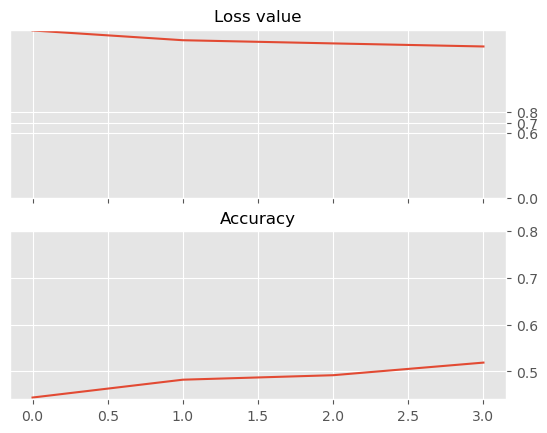

In [12]:
# plot the result
# import pandas as pd
records = pd.read_csv(modelname+'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
#plt.plot(records['val_acc'])
plt.plot(records['val_accuracy'])
#plt.plot(records.get('val_accuracy', records.get('val_acc')))
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()

# plot the model

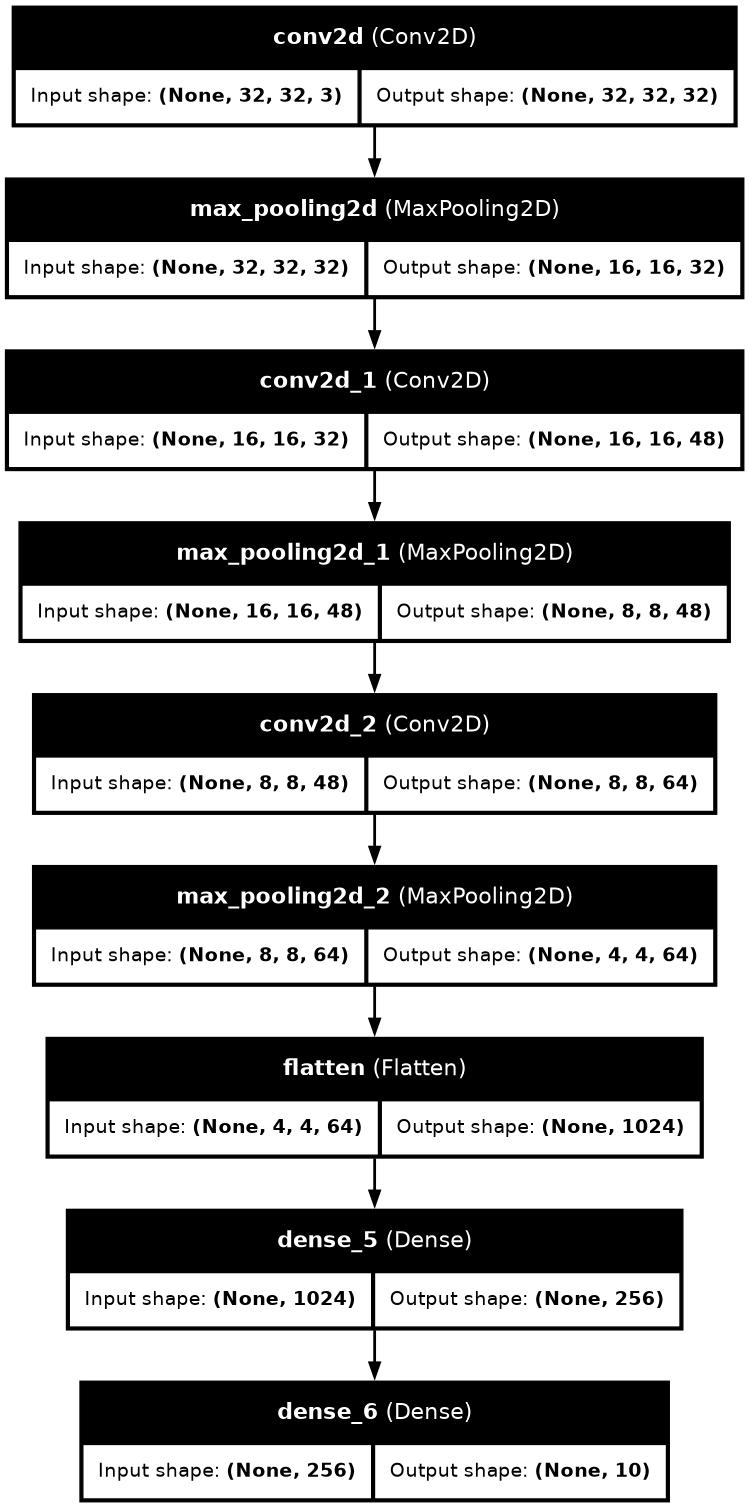

In [51]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model

# Load the full model (if you saved it as .keras)
# model = load_model('cifar10.keras')

# Create model visualization
plot_model(
    modelGo,                        # Model to visualize
    to_file='cifar10_CNN_model.png',   # Output image filename
    show_shapes=True,              # Display input/output shapes per layer
    show_layer_names=True,         # Display layer names
    expand_nested=False,           # Expand nested models if you have any
    dpi=100                        # Image resolution
)
